# Stuff+ Model: Separated Models by Pitch Category

Trains three independent LightGBM models — one per pitch category — using walk-forward cross-validation.

| Model | Pitch Types |
|---|---|
| **Fastball** | FF, SI, FC |
| **Breaking Ball** | SL, ST, CU, KC, SV |
| **Offspeed** | CH, FS |

**Rationale:** Each category has directionally different relationships (e.g., high `az` is elite for fastballs, bad for curveballs). Separate models learn each category's signal cleanly without fighting the others.

After training, all three models' predictions are pooled and scaled together to the same 20-80 scouting scale, enabling cross-category leaderboard comparisons.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp -r "/content/drive/MyDrive/stuff_model/data/" "/content/"

In [3]:
!mkdir /content/model_storage/

In [4]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import root_mean_squared_error
from scipy import stats
import joblib

import shap
from scipy.stats import zscore
from tqdm.notebook import tqdm

In [5]:
%matplotlib inline

In [6]:
# ── Configuration ────────────────────────────────────────────

PITCH_CATEGORIES = {
    'Fastball':     ['FF', 'SI', 'FC', 'FA'],        # FA = generic fastball tag
    'BreakingBall': ['SL', 'ST', 'CU', 'KC', 'SV'],
    'Offspeed':     ['CH', 'FS', 'FO'],              # FO = forkball, similar to FS
}

# Color palette — consistent across all plots
PITCH_TYPE_COLORS = {
    'FF': 'steelblue',     'SI': 'dodgerblue',    'FC': 'lightblue',    'FA': 'cornflowerblue',
    'SL': 'tomato',        'ST': 'orangered',      'CU': 'firebrick',
    'KC': 'salmon',        'SV': 'lightsalmon',
    'CH': 'seagreen',      'FS': 'mediumseagreen', 'FO': 'darkseagreen',
}
CATEGORY_COLORS = {
    'Fastball': 'steelblue', 'BreakingBall': 'tomato', 'Offspeed': 'seagreen',
}

features = [
    'release_speed',
    'release_spin_rate',
    'spin_axis',
    'release_extension',
    'az',
    'ax',
    'release_pos_x',
    'release_pos_z',
    'speed_diff',
    'az_diff',
    'ax_diff',
    'stand',
    'p_throws',
    # Approach angle features
    'VAA',
    'HAA',
    'vaa_diff',
    # SSW proxy features
    'ssw_x',
    'ssw_z',
    'ssw_magnitude',
]

categorical_cols = ['p_throws', 'stand']
target = 'target'
seed   = 1126

## Helper Functions

In [7]:
def evaluate_cv_results(cv_scores, label=''):
    """Print walk-forward CV results."""
    tag = f' [{label}]' if label else ''
    print(f'Walk-Forward RMSE scores{tag}: {[f"{s:.6f}" for s in cv_scores]}')
    print(f'Mean CV RMSE{tag}: {np.mean(cv_scores):.6f}')
    print(f'Std CV RMSE{tag}:  {np.std(cv_scores):.6f}')
    return np.mean(cv_scores)

In [8]:
def calculate_stuff_plus(df, ref_mean, ref_std):
    """Scale model predictions to the 20-80 scouting scale."""
    z_scores   = (df['y_pred'].values - ref_mean) / ref_std
    stuff_plus = np.clip(50 - z_scores * 10, 20, 80)
    df = df.copy()
    df['stuff_plus'] = stuff_plus
    return df

In [9]:
def perform_split_half_analysis(groups, sample_size, n_iterations=10):
    """
    Split-half reliability for a given sample size across pitcher-pitch groups.
    Uses Spearman-Brown correction to estimate full-sample reliability.
    """
    rel_scores = []
    for _ in range(n_iterations):
        means_a, means_b = [], []
        for group in groups:
            sample     = group.sample(n=sample_size, replace=False)
            half_point = sample_size // 2
            means_a.append(sample.iloc[:half_point]['stuff_plus'].mean())
            means_b.append(sample.iloc[half_point:2*half_point]['stuff_plus'].mean())

        if len(means_a) >= 20:
            corr = np.corrcoef(means_a, means_b)[0, 1]
            if not np.isnan(corr) and -1.0 < corr < 1.0:
                rel_scores.append((2 * corr) / (1 + corr))  # Spearman-Brown

    return (np.mean(rel_scores), np.std(rel_scores)) if rel_scores else (np.nan, np.nan)


def calculate_reliability_by_sample_size(df, pitch_type, sample_sizes=None):
    """Calculate split-half reliability at increasing sample sizes for one pitch type."""
    if sample_sizes is None:
        sample_sizes = [50, 100, 150, 200, 300, 500, 750, 1000]

    df_pt      = df[df['pitch_type'] == pitch_type].copy()
    all_groups = [g for _, g in df_pt.groupby(['pitcher', 'pitch_type'])]

    results = []
    for n in sample_sizes:
        valid_groups = [g for g in all_groups if len(g) >= n]
        if len(valid_groups) < 20:
            continue
        rel, std_rel = perform_split_half_analysis(valid_groups, n, n_iterations=10)
        if not np.isnan(rel):
            results.append({'sample_size': n, 'reliability': rel,
                            'std': std_rel, 'n_groups': len(valid_groups)})

    return pd.DataFrame(results)


def pitcher_level_means(df, year, pitch_types=None, min_pitches=200):
    """Return pitcher-level mean Stuff+ for a given year, filtered by min pitch count."""
    d = df[df['game_year'] == year]
    if pitch_types:
        d = d[d['pitch_type'].isin(pitch_types)]
    g   = d.groupby(['pitcher', 'pitch_type'])['stuff_plus'].agg(['mean', 'count'])
    return g[g['count'] >= min_pitches]['mean']

## Prepare Data

In [10]:
# Load preprocessed training data
all_data = pl.read_csv('./data/train_data.csv')

In [11]:
# Convert categorical columns
all_data = all_data.with_columns([
    pl.col('p_throws').cast(pl.Categorical),
    pl.col('stand').cast(pl.Categorical),
])

In [12]:
# Drop nulls on model columns and convert to pandas
all_data = all_data.drop_nulls(subset=features + [target])
all_data = all_data.to_pandas()

for col in categorical_cols:
    all_data[col] = all_data[col].astype('category')

print(f'Total samples: {len(all_data):,}')
print(f'Features:      {len(features)}')
print(f'Years present: {sorted(all_data["game_year"].unique())}')

for cat, pitch_types in PITCH_CATEGORIES.items():
    n = all_data['pitch_type'].isin(pitch_types).sum()
    print(f'  {cat:15s}: {n:>9,} pitches ({pitch_types})')

Total samples: 2,815,090
Features:      19
Years present: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
  Fastball       : 1,593,659 pitches (['FF', 'SI', 'FC', 'FA'])
  BreakingBall   :   853,954 pitches (['SL', 'ST', 'CU', 'KC', 'SV'])
  Offspeed       :   367,477 pitches (['CH', 'FS', 'FO'])


## Train Separated Models

For each pitch category:
1. Filter to category pitch types
2. Walk-forward cross-validation (3 folds)
3. Train final model on all years
4. Save model

In [13]:
# Walk-forward (expanding window) splits — same definition as unified model
walk_forward_splits = [
    {'train_years': [2021],             'val_year': 2022, 'fold': 1},
    {'train_years': [2021, 2022],       'val_year': 2023, 'fold': 2},
    {'train_years': [2021, 2022, 2023], 'val_year': 2024, 'fold': 3},
]

In [14]:
# LightGBM parameters
lgb_params = {
    'objective':    'regression',
    'metric':       'rmse',
    'device_type':  'cpu',
    'num_threads':  -1,
    'learning_rate': 0.02,
    'random_state':  seed,
}
lgb_num_rounds = 1000

In [15]:
# ── Main training loop ───────────────────────────────────────
trained_models = {}   # category → lgb model
cv_results     = {}   # category → mean RMSE

for category, pitch_types in PITCH_CATEGORIES.items():
    print('\n' + '=' * 70)
    print(f'CATEGORY: {category}  ({pitch_types})')
    print('=' * 70)

    cat_mask = all_data['pitch_type'].isin(pitch_types)
    cat_data = all_data[cat_mask].copy()
    cat_x    = cat_data[features]
    cat_y    = cat_data[target]
    print(f'  Pitches: {len(cat_data):,}')

    fold_scores = []
    for split in walk_forward_splits:
        fold       = split['fold']
        train_mask = cat_data['game_year'].isin(split['train_years'])
        val_mask   = cat_data['game_year'] == split['val_year']

        x_tr, x_va = cat_x[train_mask], cat_x[val_mask]
        y_tr, y_va = cat_y[train_mask], cat_y[val_mask]

        d_tr = lgb.Dataset(x_tr, label=y_tr, categorical_feature=categorical_cols)
        d_va = lgb.Dataset(x_va, label=y_va, reference=d_tr)

        model_fold = lgb.train(lgb_params, d_tr, lgb_num_rounds)
        rmse = root_mean_squared_error(y_va, model_fold.predict(x_va))
        fold_scores.append(rmse)
        print(f'  Fold {fold}: Train {split["train_years"]} → Val {split["val_year"]}  '
              f'(train={len(x_tr):,}, val={len(x_va):,})  RMSE={rmse:.6f}')

    mean_rmse = evaluate_cv_results(fold_scores, label=category)
    cv_results[category] = mean_rmse

    print(f'\n  Training final {category} model on all {len(cat_data):,} pitches...')
    d_all       = lgb.Dataset(cat_x, label=cat_y, categorical_feature=categorical_cols)
    final_model = lgb.train(lgb_params, d_all, lgb_num_rounds)
    trained_models[category] = final_model

    model_path = f'./model_storage/lgb_{category.lower()}_model.joblib'
    joblib.dump(final_model, model_path)
    print(f'  Saved → {model_path}')


CATEGORY: Fastball  (['FF', 'SI', 'FC', 'FA'])
  Pitches: 1,593,659
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084984 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4052
[LightGBM] [Info] Number of data points in the train set: 407597, number of used features: 19
[LightGBM] [Info] Start training from score 0.001593
  Fold 1: Train [2021] → Val 2022  (train=407,597, val=396,674)  RMSE=0.214613
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.273617 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4069
[LightGBM] [Info] Number of data points in the train set: 804271, number of used features: 19
[LightGBM] [Info] Start training from score 0.000599
  Fold 2: Train [2021, 2022] → Val 2023  (train=804,271, val=396,393)  RMSE=0.219401
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing

## CV Results Summary

In [16]:
print('\n' + '=' * 50)
print('WALK-FORWARD CV RMSE — SEPARATED MODELS')
print('=' * 50)
for cat, rmse in cv_results.items():
    print(f'  {cat:15s}: {rmse:.6f}')
print('\nNote: compare to unified model walk-forward RMSE from stuff_model_regression.ipynb')


WALK-FORWARD CV RMSE — SEPARATED MODELS
  Fastball       : 0.216595
  BreakingBall   : 0.208012
  Offspeed       : 0.212569

Note: compare to unified model walk-forward RMSE from stuff_model_regression.ipynb


## Generate Combined Predictions & Unified Stuff+ Scale

Each pitch is scored by its category model, then all predictions are pooled
to define one shared 20-80 scale — so a Fastball 60 means the same as a Slider 60.

In [17]:
all_data['y_pred'] = np.nan

for category, pitch_types in PITCH_CATEGORIES.items():
    cat_mask = all_data['pitch_type'].isin(pitch_types)
    model    = trained_models[category]
    all_data.loc[cat_mask, 'y_pred'] = model.predict(all_data.loc[cat_mask, features])
    print(f'{category:15s}: {cat_mask.sum():>9,} predictions generated')

unmatched = all_data['y_pred'].isna().sum()
if unmatched > 0:
    print(f'Warning: {unmatched:,} pitches had no matching category model')
    all_data = all_data.dropna(subset=['y_pred'])

print(f'\nTotal predictions: {len(all_data):,}')

Fastball       : 1,593,659 predictions generated
BreakingBall   :   853,954 predictions generated
Offspeed       :   367,477 predictions generated

Total predictions: 2,815,090


In [18]:
ref_mean = all_data['y_pred'].mean()
ref_std  = all_data['y_pred'].std()

print(f'Unified Stuff+ Scaling Reference:')
print(f'  ref_mean = {ref_mean:.6f}')
print(f'  ref_std  = {ref_std:.6f}')

scaler_path = './model_storage/stuff_plus_separated_scaler.joblib'
joblib.dump({'ref_mean': ref_mean, 'ref_std': ref_std}, scaler_path)
print(f'Scaler saved → {scaler_path}')

Unified Stuff+ Scaling Reference:
  ref_mean = -0.000027
  ref_std  = 0.024884
Scaler saved → ./model_storage/stuff_plus_separated_scaler.joblib


In [19]:
all_data = calculate_stuff_plus(all_data, ref_mean, ref_std)

print(f'Stuff+ range: {all_data["stuff_plus"].min():.1f} – {all_data["stuff_plus"].max():.1f}')
print(f'Stuff+ mean:  {all_data["stuff_plus"].mean():.2f}')
print(f'Stuff+ std:   {all_data["stuff_plus"].std():.2f}')

Stuff+ range: 20.0 – 80.0
Stuff+ mean:  50.11
Stuff+ std:   9.52


## Analysis

### Feature Importance by Category

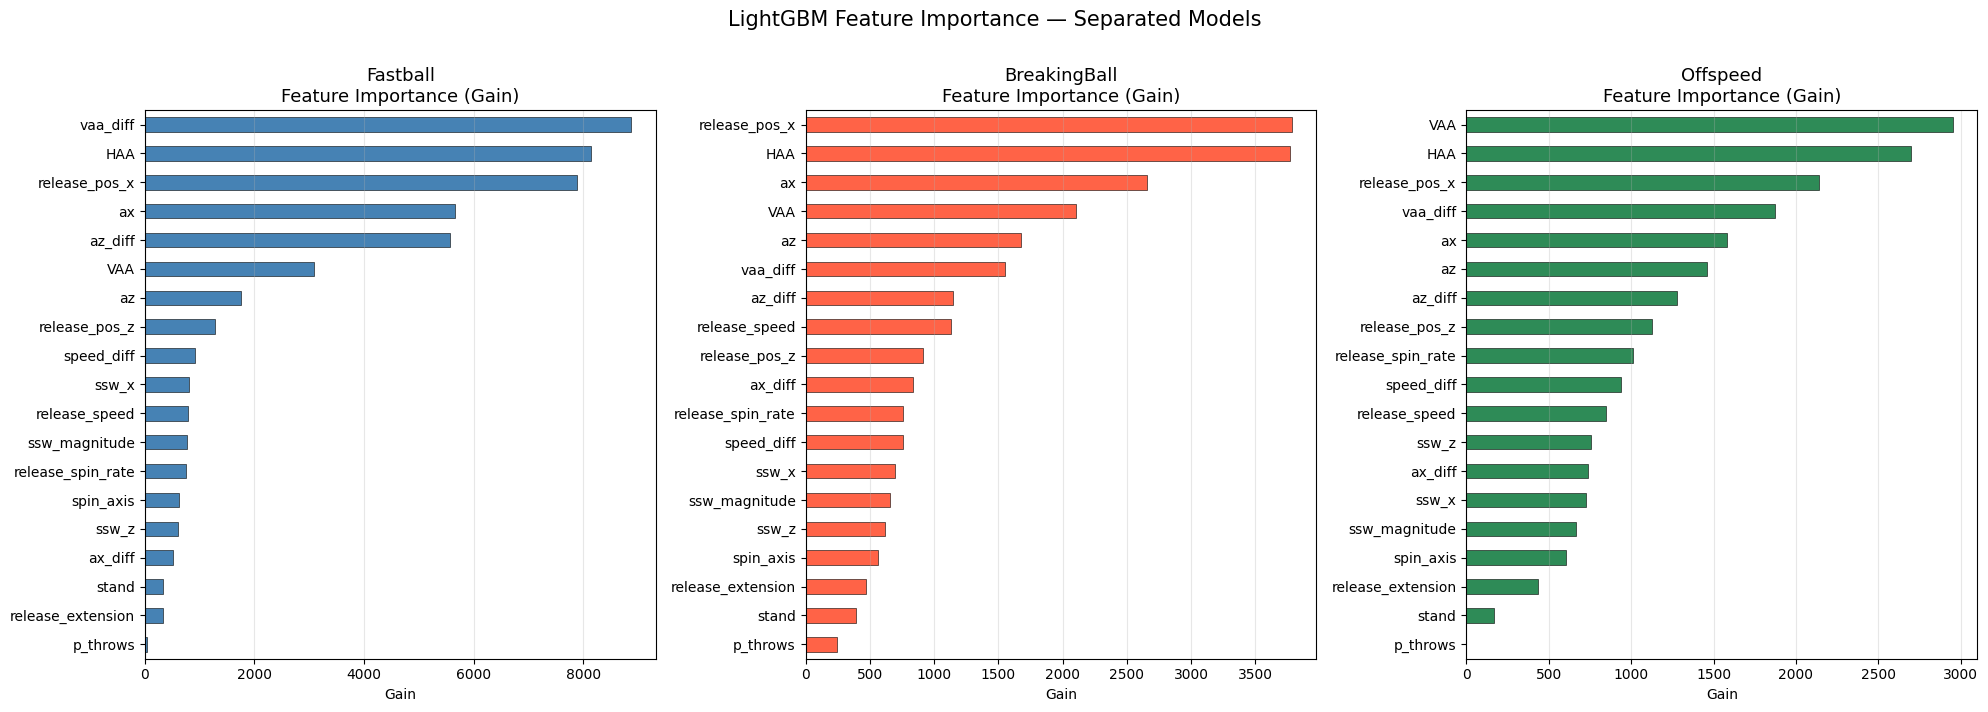

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (category, model) in zip(axes, trained_models.items()):
    importance = pd.Series(
        model.feature_importance(importance_type='gain'),
        index=features
    ).sort_values(ascending=True)

    importance.plot(kind='barh', ax=ax, color=CATEGORY_COLORS[category], edgecolor='black', linewidth=0.4)
    ax.set_title(f'{category}\nFeature Importance (Gain)', fontsize=13)
    ax.set_xlabel('Gain')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('LightGBM Feature Importance — Separated Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Stuff+ Distribution by Category and Pitch Type

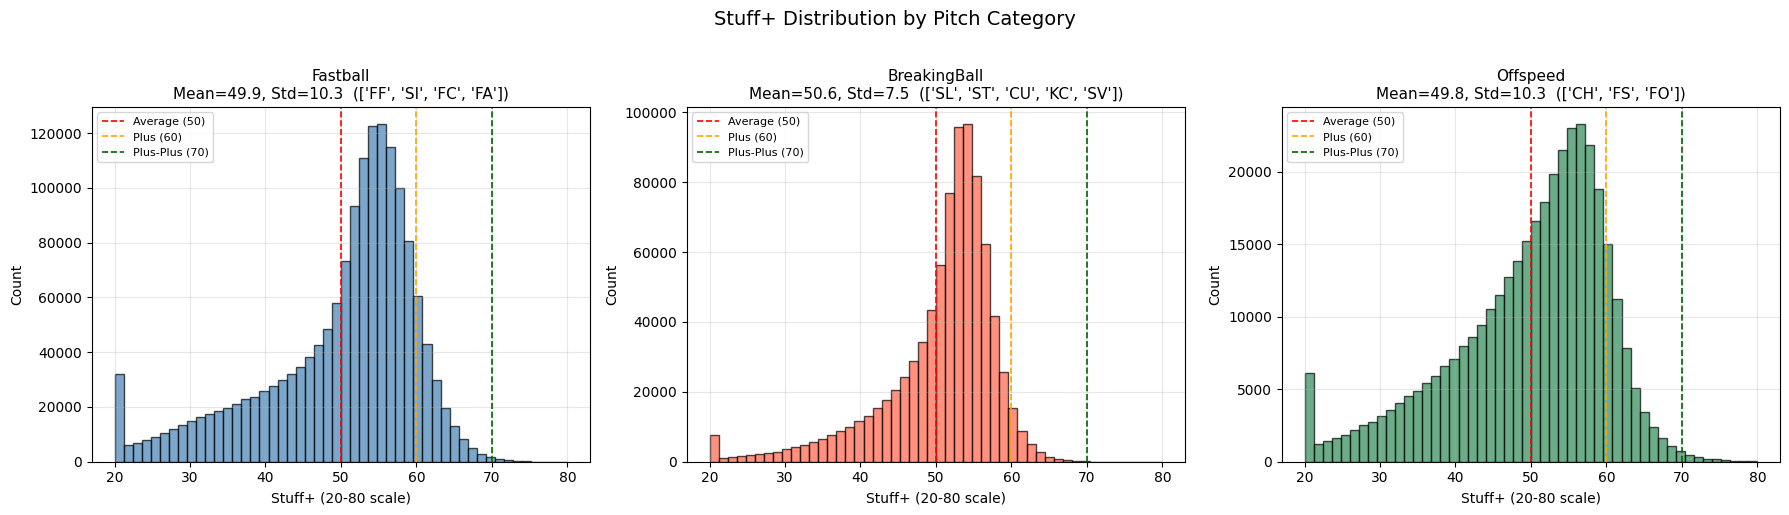

In [21]:
# ── Histogram per category ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (category, pitch_types) in zip(axes, PITCH_CATEGORIES.items()):
    cat_data = all_data[all_data['pitch_type'].isin(pitch_types)]
    ax.hist(cat_data['stuff_plus'], bins=50, edgecolor='black', alpha=0.7,
            color=CATEGORY_COLORS[category])
    ax.axvline(50, color='red',       linestyle='--', linewidth=1.2, label='Average (50)')
    ax.axvline(60, color='orange',    linestyle='--', linewidth=1.2, label='Plus (60)')
    ax.axvline(70, color='darkgreen', linestyle='--', linewidth=1.2, label='Plus-Plus (70)')
    ax.set_xlabel('Stuff+ (20-80 scale)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    mean_sp = cat_data['stuff_plus'].mean()
    std_sp  = cat_data['stuff_plus'].std()
    ax.set_title(f'{category}\nMean={mean_sp:.1f}, Std={std_sp:.1f}  ({pitch_types})', fontsize=11)

plt.suptitle('Stuff+ Distribution by Pitch Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

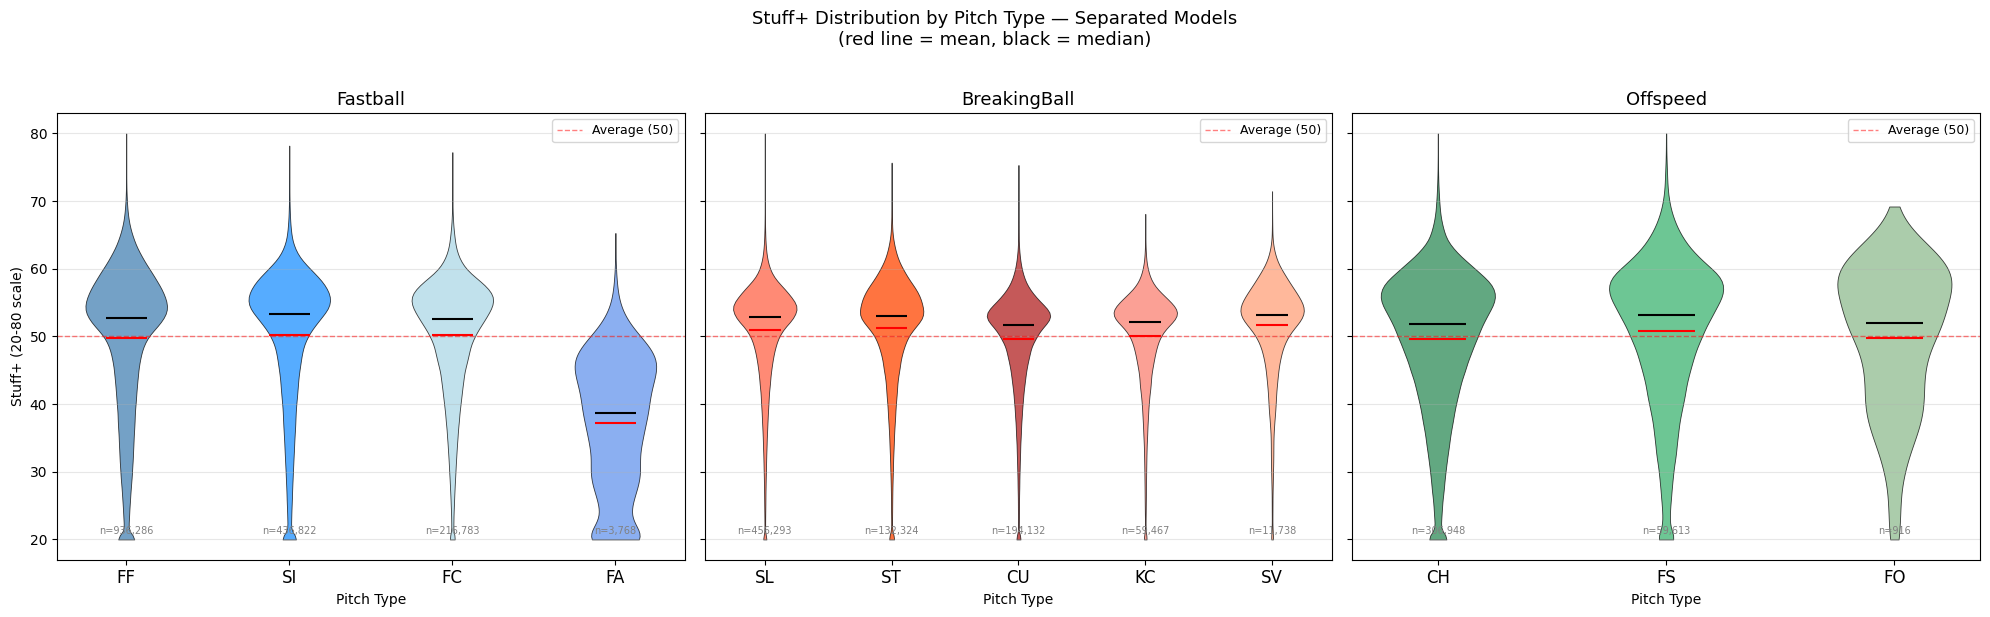

In [22]:
# ── Violin plot per pitch type within each category ──────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (category, pitch_types) in zip(axes, PITCH_CATEGORIES.items()):
    pt_present  = [pt for pt in pitch_types if (all_data['pitch_type'] == pt).sum() > 0]
    data_list   = [all_data[all_data['pitch_type'] == pt]['stuff_plus'].values
                   for pt in pt_present]

    parts = ax.violinplot(data_list, positions=range(len(pt_present)),
                          showmeans=True, showmedians=True, showextrema=False)

    for body, pt in zip(parts['bodies'], pt_present):
        body.set_facecolor(PITCH_TYPE_COLORS.get(pt, 'gray'))
        body.set_edgecolor('black')
        body.set_linewidth(0.6)
        body.set_alpha(0.75)

    parts['cmedians'].set_color('black')
    parts['cmeans'].set_color('red')

    ax.set_xticks(range(len(pt_present)))
    ax.set_xticklabels(pt_present, fontsize=12)
    ax.axhline(50, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Average (50)')
    ax.set_title(f'{category}', fontsize=13)
    ax.set_xlabel('Pitch Type')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9)

    # Annotate count per pitch type
    for i, pt in enumerate(pt_present):
        n = (all_data['pitch_type'] == pt).sum()
        ax.text(i, 20.5, f'n={n:,}', ha='center', va='bottom', fontsize=7, color='gray')

axes[0].set_ylabel('Stuff+ (20-80 scale)')
plt.suptitle('Stuff+ Distribution by Pitch Type — Separated Models\n'
             '(red line = mean, black = median)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Stuff+ Summary Statistics by Pitch Type

In [23]:
print('\n' + '=' * 60)
print('STUFF+ SUMMARY BY PITCH TYPE')
print('=' * 60)

rows = []
for category, pitch_types in PITCH_CATEGORIES.items():
    for pt in pitch_types:
        pt_data = all_data[all_data['pitch_type'] == pt]['stuff_plus']
        if len(pt_data) > 0:
            rows.append({
                'Category':  category,
                'PitchType': pt,
                'Count':     len(pt_data),
                'Mean':      round(pt_data.mean(), 2),
                'Std':       round(pt_data.std(),  2),
                'P25':       round(pt_data.quantile(0.25), 2),
                'Median':    round(pt_data.median(), 2),
                'P75':       round(pt_data.quantile(0.75), 2),
            })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))


STUFF+ SUMMARY BY PITCH TYPE
    Category PitchType  Count  Mean   Std   P25  Median   P75
    Fastball        FF 936286 49.75 10.66 44.37   52.73 57.03
    Fastball        SI 436822 50.24 10.01 46.13   53.36 56.93
    Fastball        FC 216783 50.22  8.70 46.13   52.58 56.17
    Fastball        FA   3768 37.28  9.77 29.56   38.63 45.42
BreakingBall        SL 456293 50.90  7.44 48.37   52.88 55.49
BreakingBall        ST 132324 51.27  7.96 48.47   53.06 56.25
BreakingBall        CU 194132 49.63  7.46 46.89   51.68 54.22
BreakingBall        KC  59467 50.11  7.09 47.65   52.18 54.48
BreakingBall        SV  11738 51.62  7.02 49.34   53.17 55.95
    Offspeed        CH 306948 49.58 10.17 43.97   51.83 56.90
    Offspeed        FS  59613 50.79 10.73 44.95   53.21 58.32
    Offspeed        FO    916 49.83 10.77 42.19   51.94 58.39


### Year-over-Year Stability

In [24]:
MIN_PITCHES = 200
year_pairs  = [(2021, 2022), (2022, 2023), (2023, 2024)]

print('\n' + '=' * 65)
print('YEAR-OVER-YEAR STABILITY (r) — SEPARATED MODELS')
print('=' * 65)
print(f'{"Category":15s}  {"21→22":>6}  {"22→23":>6}  {"23→24":>6}  {"Mean r":>7}  {"Mean R²":>8}')
print('-' * 65)

for category, pitch_types in PITCH_CATEGORIES.items():
    corrs = []
    for y1, y2 in year_pairs:
        m1 = pitcher_level_means(all_data, y1, pitch_types, MIN_PITCHES).rename('y1')
        m2 = pitcher_level_means(all_data, y2, pitch_types, MIN_PITCHES).rename('y2')
        merged = pd.concat([m1, m2], axis=1).dropna()
        if len(merged) >= 10:
            corrs.append(np.corrcoef(merged['y1'], merged['y2'])[0, 1])
        else:
            corrs.append(np.nan)
    mean_r  = np.nanmean(corrs)
    mean_r2 = mean_r ** 2
    corr_strs = '  '.join(f'{c:>6.4f}' if not np.isnan(c) else '   N/A' for c in corrs)
    print(f'{category:15s}  {corr_strs}  {mean_r:>7.4f}  {mean_r2:>8.4f}')


YEAR-OVER-YEAR STABILITY (r) — SEPARATED MODELS
Category          21→22   22→23   23→24   Mean r   Mean R²
-----------------------------------------------------------------
Fastball         0.7420  0.7670  0.7995   0.7695    0.5921
BreakingBall     0.8571  0.8042  0.8262   0.8292    0.6875
Offspeed         0.7113  0.8570  0.7496   0.7726    0.5970


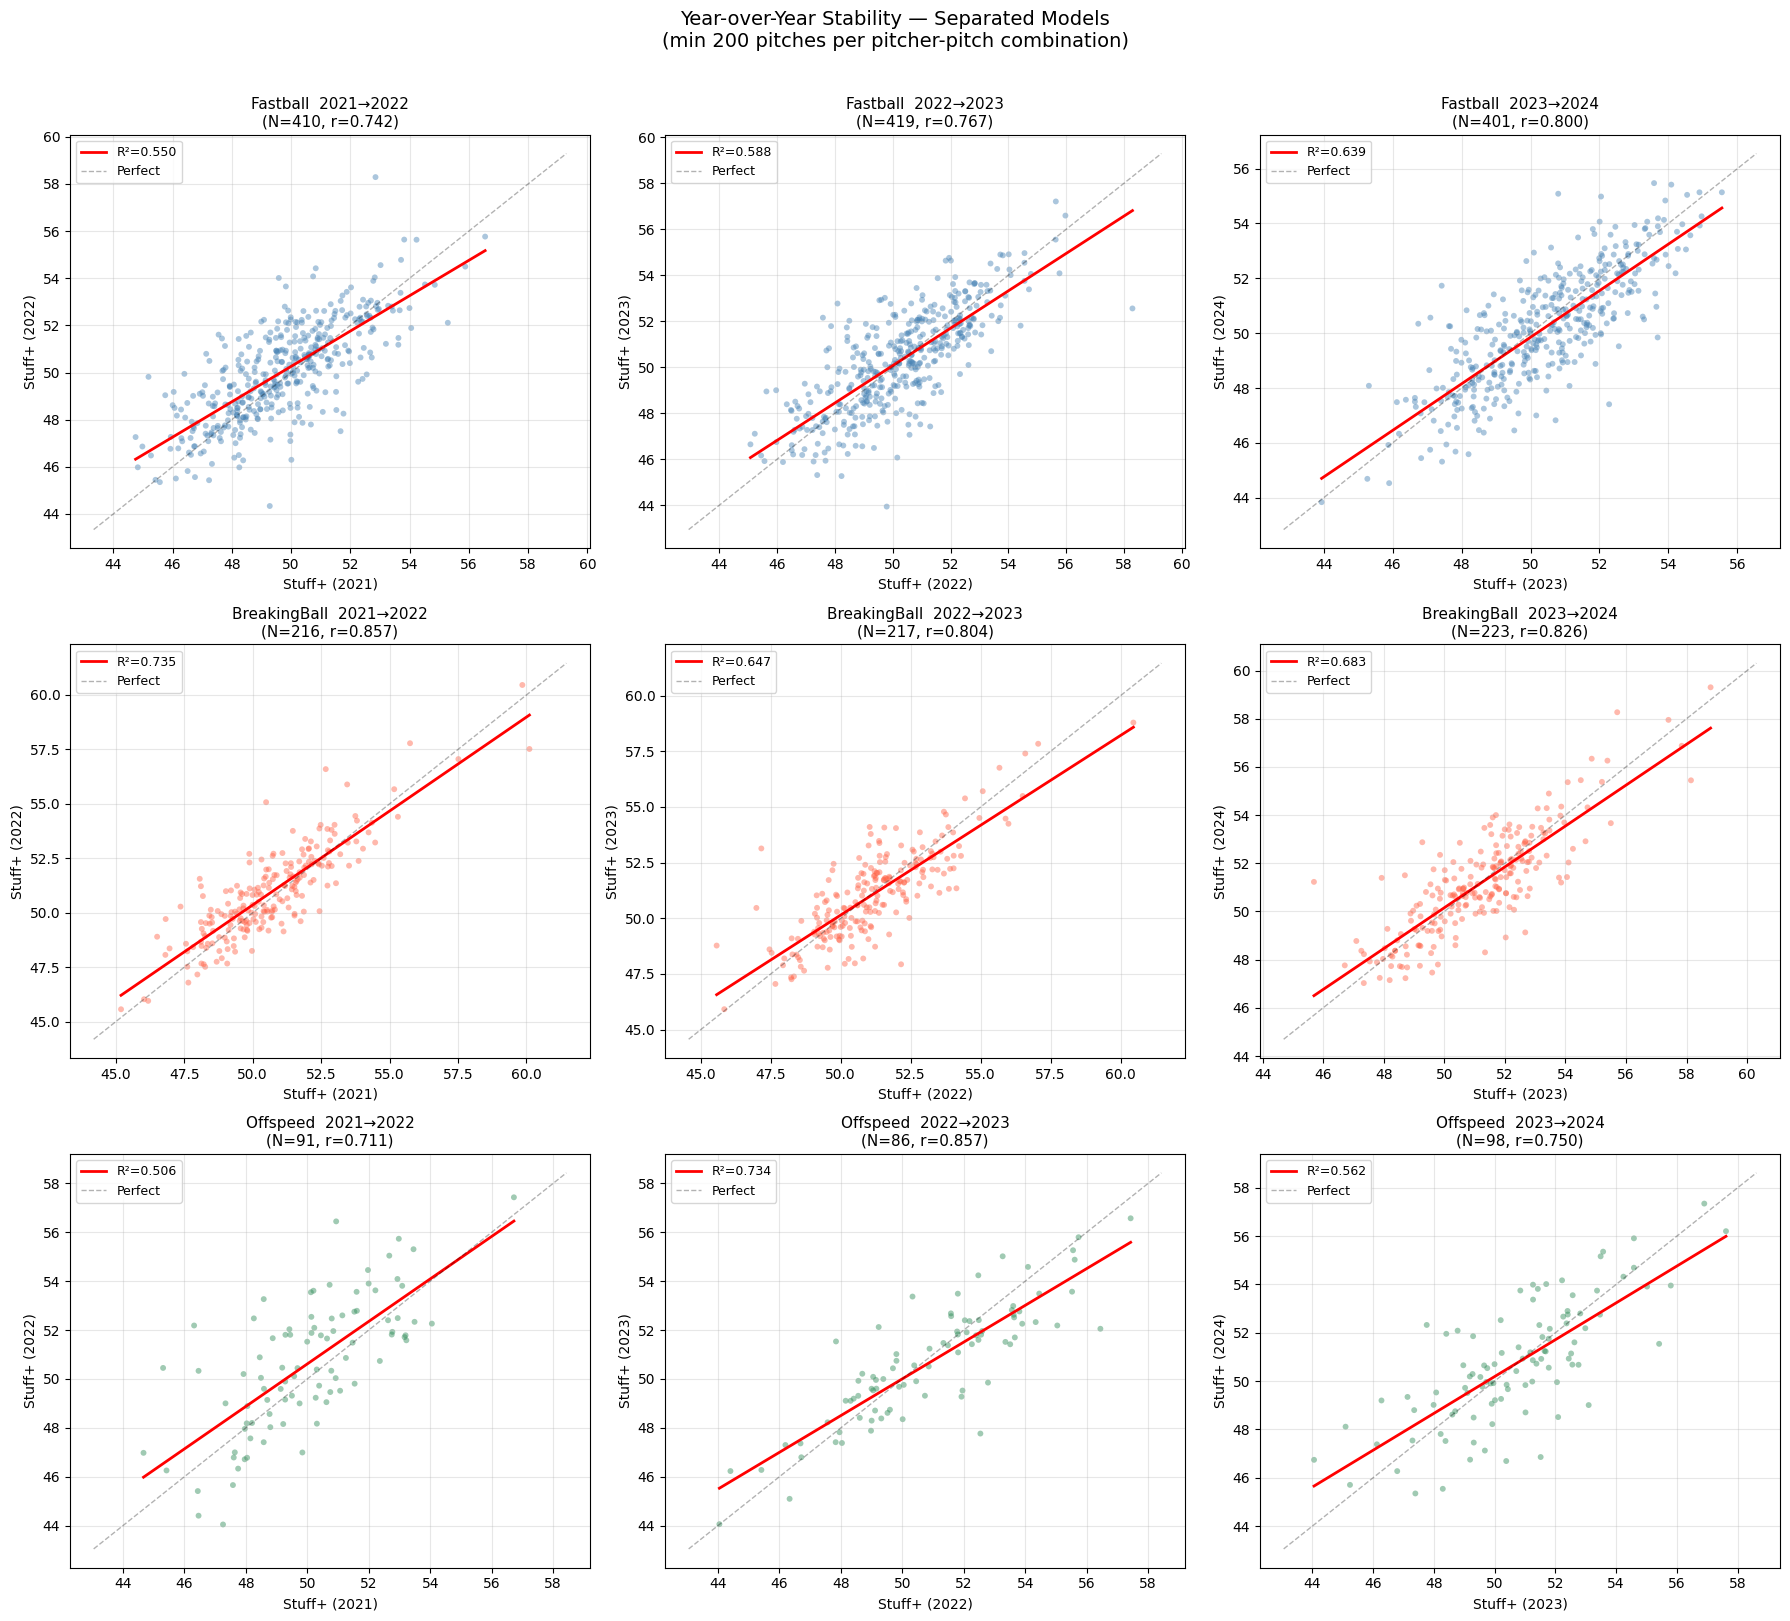

In [25]:
# ── YoY scatter plots: 3 rows (categories) × 3 cols (year transitions) ──
fig, axes = plt.subplots(3, 3, figsize=(18, 16))

for row_idx, (category, pitch_types) in enumerate(PITCH_CATEGORIES.items()):
    for col_idx, (y1, y2) in enumerate(year_pairs):
        ax = axes[row_idx, col_idx]

        m1 = pitcher_level_means(all_data, y1, pitch_types, MIN_PITCHES).rename('y1')
        m2 = pitcher_level_means(all_data, y2, pitch_types, MIN_PITCHES).rename('y2')
        merged = pd.concat([m1, m2], axis=1).dropna()

        if len(merged) >= 10:
            r  = np.corrcoef(merged['y1'], merged['y2'])[0, 1]
            r2 = r ** 2

            ax.scatter(merged['y1'], merged['y2'],
                       alpha=0.45, s=18, color=CATEGORY_COLORS[category], edgecolors='none')

            # Regression line
            slope, intercept, *_ = stats.linregress(merged['y1'], merged['y2'])
            x_lo, x_hi = merged['y1'].min(), merged['y1'].max()
            ax.plot([x_lo, x_hi], [slope*x_lo+intercept, slope*x_hi+intercept],
                    'r-', linewidth=2, label=f'R²={r2:.3f}')

            # 1:1 reference
            lo = min(merged['y1'].min(), merged['y2'].min()) - 1
            hi = max(merged['y1'].max(), merged['y2'].max()) + 1
            ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, linewidth=1, label='Perfect')

            ax.set_xlabel(f'Stuff+ ({y1})', fontsize=10)
            ax.set_ylabel(f'Stuff+ ({y2})', fontsize=10)
            ax.set_title(f'{category}  {y1}→{y2}\n(N={len(merged)}, r={r:.3f})', fontsize=11)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, f'Insufficient data\n(N={len(merged)})',
                    ha='center', va='center', transform=ax.transAxes, fontsize=11)
            ax.set_title(f'{category}  {y1}→{y2}', fontsize=11)

plt.suptitle('Year-over-Year Stability — Separated Models\n'
             f'(min {MIN_PITCHES} pitches per pitcher-pitch combination)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

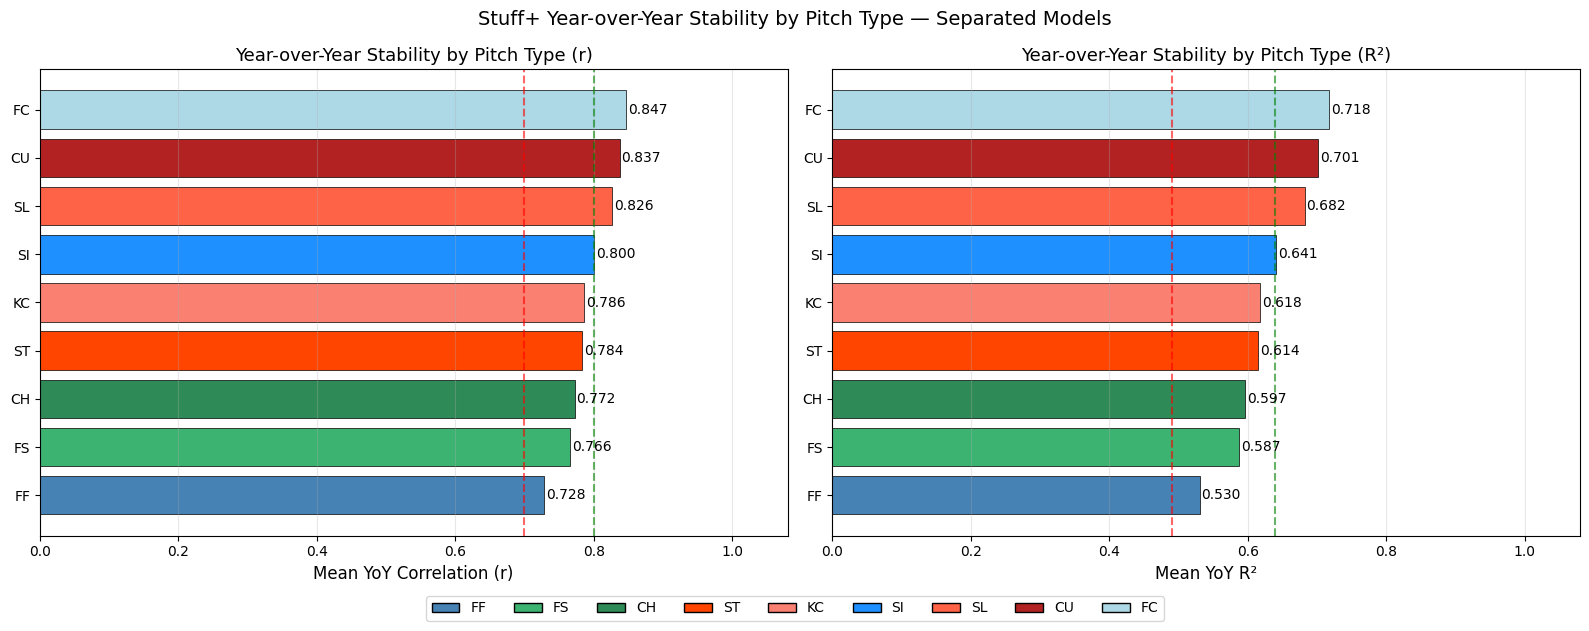

In [26]:
# ── YoY stability bar chart per individual pitch type ────────
pt_stabilities = []

for category, pitch_types in PITCH_CATEGORIES.items():
    for pt in pitch_types:
        pt_data = all_data[all_data['pitch_type'] == pt]
        if len(pt_data) < 5000:
            continue

        corrs = []
        for y1, y2 in year_pairs:
            m1 = (pt_data[pt_data['game_year'] == y1]
                  .groupby('pitcher')['stuff_plus']
                  .agg(['mean', 'count']))
            m1 = m1[m1['count'] >= MIN_PITCHES]['mean'].rename('y1')
            m2 = (pt_data[pt_data['game_year'] == y2]
                  .groupby('pitcher')['stuff_plus']
                  .agg(['mean', 'count']))
            m2 = m2[m2['count'] >= MIN_PITCHES]['mean'].rename('y2')
            merged = pd.concat([m1, m2], axis=1).dropna()
            if len(merged) >= 10:
                corrs.append(np.corrcoef(merged['y1'], merged['y2'])[0, 1])

        if corrs:
            pt_stabilities.append({
                'Category':  category,
                'PitchType': pt,
                'Mean_r':    np.nanmean(corrs),
                'Mean_R2':   np.nanmean(corrs) ** 2,
            })

stab_df     = pd.DataFrame(pt_stabilities).sort_values('Mean_r', ascending=True)
bar_colors  = [PITCH_TYPE_COLORS.get(row['PitchType'], 'gray')
               for _, row in stab_df.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: r values
ax = axes[0]
bars = ax.barh(stab_df['PitchType'], stab_df['Mean_r'],
               color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axvline(0.70, color='red',   linestyle='--', alpha=0.6, linewidth=1.5, label='Good (0.70)')
ax.axvline(0.80, color='green', linestyle='--', alpha=0.6, linewidth=1.5, label='Excellent (0.80)')
for bar, val in zip(bars, stab_df['Mean_r']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Mean YoY Correlation (r)', fontsize=12)
ax.set_title('Year-over-Year Stability by Pitch Type (r)', fontsize=13)
ax.set_xlim(0, 1.08)
ax.grid(axis='x', alpha=0.3)

# Right: R² values
ax = axes[1]
bars = ax.barh(stab_df['PitchType'], stab_df['Mean_R2'],
               color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axvline(0.49, color='red',   linestyle='--', alpha=0.6, linewidth=1.5, label='Good (0.70²)')
ax.axvline(0.64, color='green', linestyle='--', alpha=0.6, linewidth=1.5, label='Excellent (0.80²)')
for bar, val in zip(bars, stab_df['Mean_R2']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)
ax.set_xlabel('Mean YoY R²', fontsize=12)
ax.set_title('Year-over-Year Stability by Pitch Type (R²)', fontsize=13)
ax.set_xlim(0, 1.08)
ax.grid(axis='x', alpha=0.3)

# Shared legend
legend_els = [mpatches.Patch(facecolor=PITCH_TYPE_COLORS.get(pt, 'gray'),
                              edgecolor='black', label=pt)
              for pt in stab_df['PitchType']]
fig.legend(handles=legend_els, loc='lower center', ncol=len(stab_df),
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Stuff+ Year-over-Year Stability by Pitch Type — Separated Models', fontsize=14)
plt.tight_layout()
plt.show()

### Split-Half Reliability by Category

How many pitches are needed for a stable Stuff+ estimate for each pitch type?
Uses split-half reliability with Spearman-Brown correction across all pitcher-pitch combinations.

In [27]:
SAMPLE_SIZES = [50, 100, 150, 200, 300, 500, 750, 1000]

pt_counts         = all_data.groupby('pitch_type').size()
active_pitch_types = pt_counts[pt_counts >= 5000].index.tolist()

reliability_by_pt = {}
for pt in sorted(active_pitch_types):
    print(f'Computing reliability for {pt}...')
    reliability_by_pt[pt] = calculate_reliability_by_sample_size(all_data, pt, SAMPLE_SIZES)

print('Done.')

Computing reliability for CH...
Computing reliability for CU...
Computing reliability for FC...
Computing reliability for FF...
Computing reliability for FS...
Computing reliability for KC...
Computing reliability for SI...
Computing reliability for SL...
Computing reliability for ST...
Computing reliability for SV...
Done.


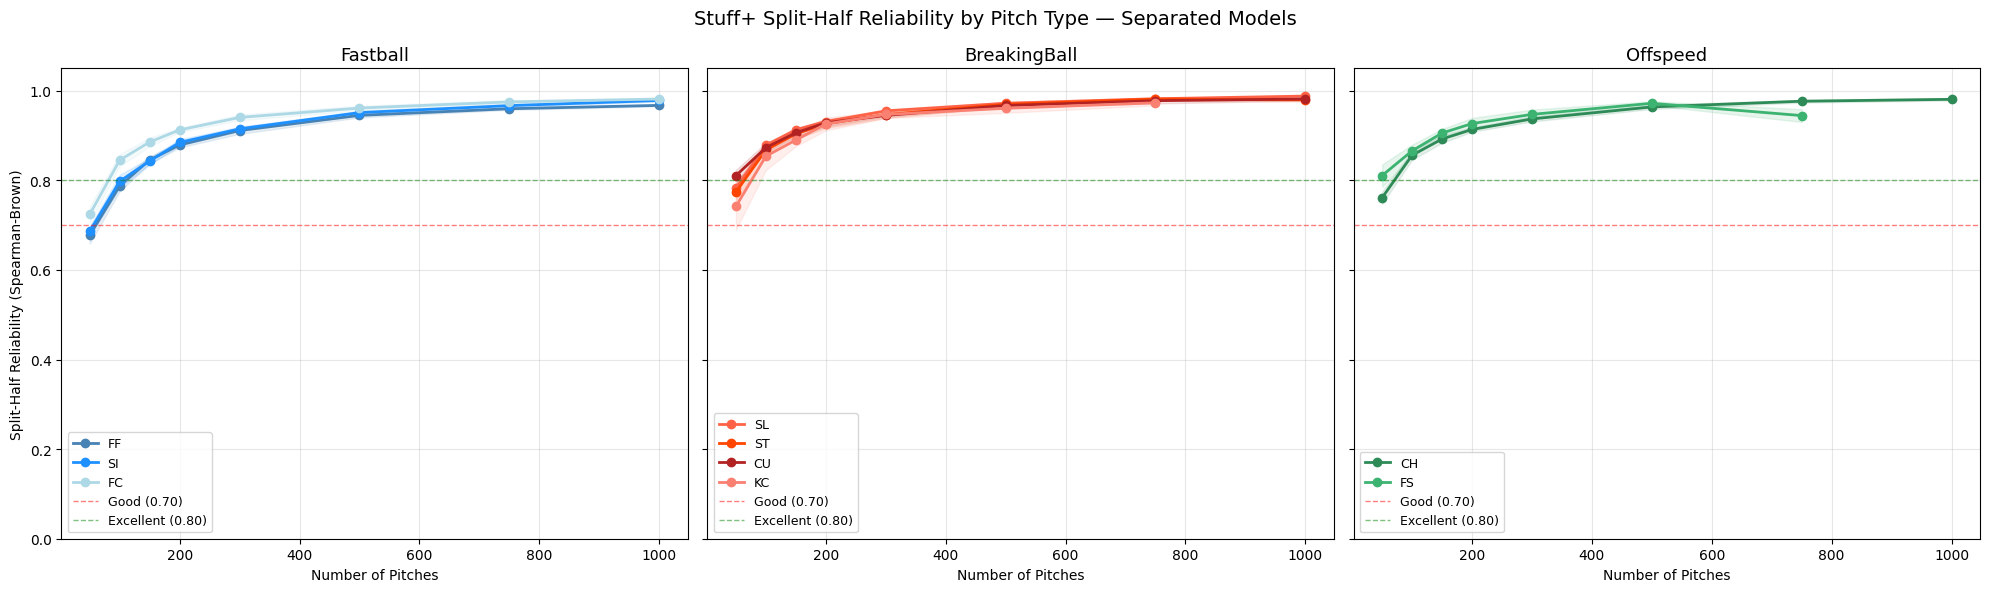

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (category, pitch_types) in zip(axes, PITCH_CATEGORIES.items()):
    for pt in pitch_types:
        if pt not in reliability_by_pt or reliability_by_pt[pt].empty:
            continue
        rel_df = reliability_by_pt[pt]
        ax.plot(rel_df['sample_size'], rel_df['reliability'],
                marker='o', linewidth=2, markersize=6,
                color=PITCH_TYPE_COLORS.get(pt, 'gray'), label=pt)
        ax.fill_between(rel_df['sample_size'],
                        rel_df['reliability'] - rel_df['std'],
                        rel_df['reliability'] + rel_df['std'],
                        color=PITCH_TYPE_COLORS.get(pt, 'gray'), alpha=0.12)

    ax.axhline(0.70, color='red',   linestyle='--', alpha=0.5, linewidth=1, label='Good (0.70)')
    ax.axhline(0.80, color='green', linestyle='--', alpha=0.5, linewidth=1, label='Excellent (0.80)')
    ax.set_title(f'{category}', fontsize=13)
    ax.set_xlabel('Number of Pitches')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel('Split-Half Reliability (Spearman-Brown)')
plt.suptitle('Stuff+ Split-Half Reliability by Pitch Type — Separated Models', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
def find_min_sample_size(rel_df, threshold):
    above = rel_df[rel_df['reliability'] >= threshold]
    return int(above.iloc[0]['sample_size']) if not above.empty else None

print('\n' + '=' * 65)
print('MINIMUM PITCHES FOR RELIABLE STUFF+ ESTIMATE')
print('=' * 65)
print(f'{"PitchType":10s}  {"Category":15s}  {"N@0.70":>8}  {"N@0.80":>8}')
print('-' * 65)

for category, pitch_types in PITCH_CATEGORIES.items():
    for pt in pitch_types:
        if pt not in reliability_by_pt or reliability_by_pt[pt].empty:
            print(f'{pt:10s}  {category:15s}  {"N/A":>8}  {"N/A":>8}')
            continue
        rel_df  = reliability_by_pt[pt]
        n70_str = str(find_min_sample_size(rel_df, 0.70) or '>1000')
        n80_str = str(find_min_sample_size(rel_df, 0.80) or '>1000')
        print(f'{pt:10s}  {category:15s}  {n70_str:>8}  {n80_str:>8}')


MINIMUM PITCHES FOR RELIABLE STUFF+ ESTIMATE
PitchType   Category           N@0.70    N@0.80
-----------------------------------------------------------------
FF          Fastball              100       150
SI          Fastball              100       150
FC          Fastball               50       100
FA          Fastball              N/A       N/A
SL          BreakingBall           50       100
ST          BreakingBall           50       100
CU          BreakingBall           50        50
KC          BreakingBall           50       100
SV          BreakingBall          N/A       N/A
CH          Offspeed               50       100
FS          Offspeed               50        50
FO          Offspeed              N/A       N/A


In [30]:
print('\n' + '=' * 65)
print('VARIANCE DECOMPOSITION — BETWEEN vs WITHIN PITCHER')
print('=' * 65)
print(f'{"Category":15s}  {"PitchType":10s}  {"BetweenStd":>11}  {"WithinStd":>10}  {"ICC":>6}')
print('-' * 65)

for category, pitch_types in PITCH_CATEGORIES.items():
    for pt in pitch_types:
        pt_data = all_data[all_data['pitch_type'] == pt]
        if len(pt_data) < 1000:
            continue
        between_var = pt_data.groupby('pitcher')['stuff_plus'].mean().var()
        within_var  = pt_data.groupby('pitcher')['stuff_plus'].var().mean()
        icc = between_var / (between_var + within_var) if (between_var + within_var) > 0 else np.nan
        print(f'{category:15s}  {pt:10s}  '
              f'{np.sqrt(between_var):>11.3f}  {np.sqrt(within_var):>10.3f}  {icc:>6.3f}')


VARIANCE DECOMPOSITION — BETWEEN vs WITHIN PITCHER
Category         PitchType    BetweenStd   WithinStd     ICC
-----------------------------------------------------------------
Fastball         FF                3.059      10.386   0.080
Fastball         SI                4.433      10.277   0.157
Fastball         FC                4.333       8.619   0.202
Fastball         FA                5.536       9.176   0.267
BreakingBall     SL                3.552       7.432   0.186
BreakingBall     ST                3.369       7.860   0.155
BreakingBall     CU                5.694       7.714   0.353
BreakingBall     KC                3.210       7.504   0.155
BreakingBall     SV                3.058       6.958   0.162
Offspeed         CH                4.910      10.630   0.176
Offspeed         FS                5.474      10.931   0.200


## Save Models to Drive

In [31]:
!cp /content/model_storage/lgb_fastball_model.joblib      "/content/drive/MyDrive/stuff_model/model_storage/"
!cp /content/model_storage/lgb_breakingball_model.joblib  "/content/drive/MyDrive/stuff_model/model_storage/"
!cp /content/model_storage/lgb_offspeed_model.joblib      "/content/drive/MyDrive/stuff_model/model_storage/"
!cp /content/model_storage/stuff_plus_separated_scaler.joblib  "/content/drive/MyDrive/stuff_model/model_storage/"
print('All models and scaler saved to Google Drive.')

All models and scaler saved to Google Drive.
